In [9]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque

In [10]:

def topo_sort(n, edges):
    adj = [[] for _ in range(n)]
    indegree = [0] * n

    # Create adjacency list and calculate indegree
    for u, v in edges:
        adj[u].append(v)
        indegree[v] += 1

    q = deque([i for i in range(n) if indegree[i] == 0])
    if not q:
        return False, []

    result = []
    while q:
        node = q.popleft()
        result.append(node)
        for neighbor in adj[node]:
            indegree[neighbor] -= 1
            if indegree[neighbor] == 0:
                q.append(neighbor)

    return (len(result) == n), result


In [11]:
def visualize_prerequisites(preReq):
    # Create a directed graph using NetworkX
    G = nx.DiGraph()

    # Add edges
    for u, v in preReq:
        G.add_edge(u, v)

    # Generate layout for better visualization
    pos = nx.spring_layout(G)

    # Plot the graph
    plt.figure(figsize=(10, 6))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color='skyblue',
        node_size=2000,
        font_size=10,
        font_weight='bold',
        edge_color='gray',
        arrowsize=20
    )

    plt.title("Course Prerequisites Graph", fontsize=16)
    plt.show()


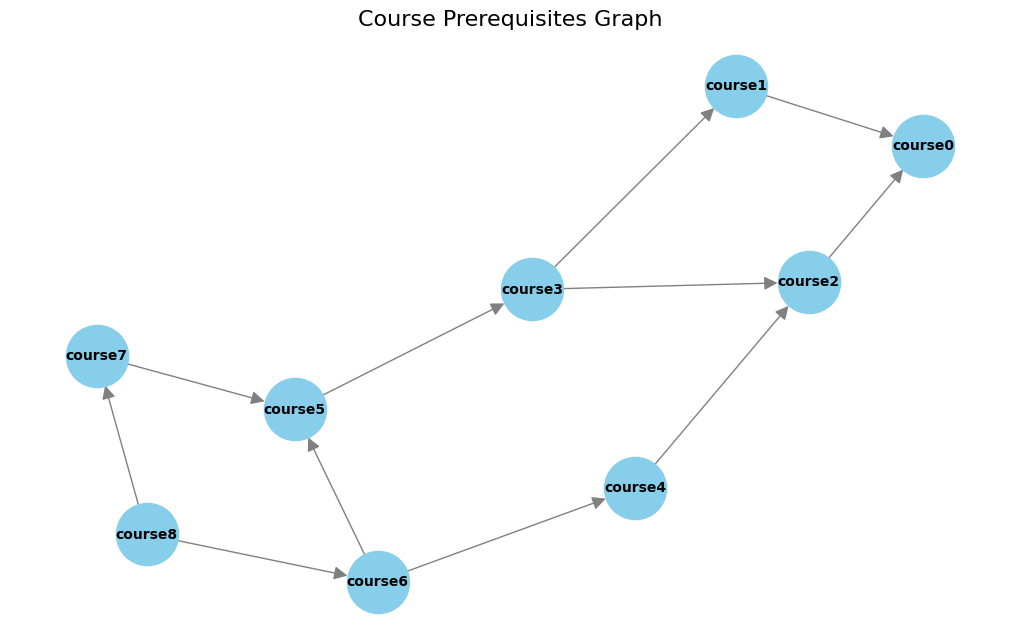

In [12]:

# Predefined input
preReq = [
    ["course1", "course0"],  # course1 depends on course0
    ["course2", "course0"],  # course2 depends on course0
    ["course3", "course1"],  # course3 depends on course1
    ["course3", "course2"],  # course3 depends on course2
    ["course4", "course2"],  # course4 depends on course2
    ["course5", "course3"],  # course5 depends on course3
    ["course6", "course4"],  # course6 depends on course4
    ["course6", "course5"],  # course6 depends on course5
    ["course7", "course5"],  # course7 depends on course5
    ["course8", "course6"],  # course8 depends on course6
    ["course8", "course7"],  # course8 depends on course7
]

visualize_prerequisites(preReq)


In [13]:

# Extract all unique courses
courses = sorted(set(course for pair in preReq for course in pair))
course_to_idx = {course: i for i, course in enumerate(courses)}
n = len(courses)

# Create edges for the graph
edges = [(course_to_idx[u], course_to_idx[v]) for u, v in preReq]


In [14]:

# Perform topological sort
is_possible, result = topo_sort(n, edges)
print(is_possible)
# Visualize graph and result
if not is_possible:
    print("Topological sorting is not possible due to a cycle.")
else:
    sorted_courses = [courses[i] for i in result]
    print(f"Topological Sort: {' -> '.join(sorted_courses)}")




True
Topological Sort: course8 -> course6 -> course7 -> course4 -> course5 -> course3 -> course1 -> course2 -> course0
